<a href="https://colab.research.google.com/github/haniamahrouse/water-segmention/blob/main/water_segmentation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# fix seeds so I get the same results every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using", device)

using cuda


In [ ]:
import shutil, zipfile
from google.colab import drive
drive.mount("/content/drive")
ZIP_PATH = "/content/drive/MyDrive/data.zip"   # change if the zip is in another folder
print("zip exists:", os.path.exists(ZIP_PATH))

# delete old unzip so I do not get double files
shutil.rmtree("/content/data", ignore_errors=True)
shutil.copy(ZIP_PATH, "/content/data.zip")
with zipfile.ZipFile("/content/data.zip") as z:
    z.extractall("/content/data")
print("unzipped")

Mounted at /content/drive
zip exists: True
unzipped


In [ ]:
DATA_ROOT = "/content/data"     # on my own computer: "data"

def find_folder(root, name):
    # walk inside root and return the first folder with this name
    for folder, subfolders, files in os.walk(root):
        if "__MACOSX" in folder:
            continue
        if os.path.basename(folder).lower() == name:
            return folder
    return None

IMAGE_DIR = find_folder(DATA_ROOT, "images")
MASK_DIR = find_folder(DATA_ROOT, "labels")
print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR:", MASK_DIR)
assert IMAGE_DIR is not None and MASK_DIR is not None, "could not find the images / labels folders, check DATA_ROOT"

# names of the 12 channels (rename the extra ones using the dataset description)
BAND_NAMES = ["Coastal", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
              "extra_8", "extra_9", "extra_10", "extra_11", "extra_12"]

# index of each band (starts from 0)
BLUE, GREEN, RED, NIR, SWIR1, SWIR2 = 1, 2, 3, 4, 5, 6

IMAGE_DIR: /content/data/data/images
MASK_DIR: /content/data/data/labels


In [ ]:
def read_image(path):
    img = tifffile.imread(path).astype(np.float32)

    # I want the shape (channels, height, width)
    if img.ndim != 3:
        raise ValueError("unexpected image shape " + str(img.shape) + " in " + path)
    if img.shape[0] != 12:
        if img.shape[-1] == 12:
            img = np.transpose(img, (2, 0, 1))
        else:
            raise ValueError("cannot find 12 bands, shape is " + str(img.shape) + " in " + path)

    img = np.nan_to_num(img)   # replace nan with 0
    return img


def read_mask(path):
    m = np.array(Image.open(path))
    m = np.squeeze(m)
    if m.ndim == 3:            # png with colour channels, use the first one
        m = m[..., 0]
    m = (m > 0).astype(np.float32)   # water = 1, not water = 0
    return m[None, :, :]             # shape (1, H, W)


def get_files(folder, endings):
    # returns a dictionary {number: full path} for names like "12.tif"
    files = {}
    skipped = []
    for name in os.listdir(folder):
        stem, ext = os.path.splitext(name)
        if ext.lower() not in endings:
            continue
        if stem.isdigit():
            files[int(stem)] = os.path.join(folder, name)
        else:
            skipped.append(name)      # odd names like "5 (1).png"
    return files, skipped

In [ ]:
image_dict, image_skipped = get_files(IMAGE_DIR, (".tif", ".tiff"))
mask_dict, mask_skipped = get_files(MASK_DIR, (".png",))

print("images:", len(image_dict), " masks:", len(mask_dict))
print("skipped image names:", len(image_skipped), image_skipped[:5])
print("skipped mask names:", len(mask_skipped), mask_skipped[:5])

# use only the numbers that exist in both folders
common = sorted(set(image_dict) & set(mask_dict))
print("pairs found:", len(common))
print("images without mask:", sorted(set(image_dict) - set(mask_dict))[:10])
print("masks without image:", len(set(mask_dict) - set(image_dict)))

images: 306  masks: 306
skipped image names: 0 []
skipped mask names: 150 ['114_220.png', '31_196.png', '58_114.png', '37_118.png', '85_117.png']
pairs found: 306
images without mask: []
masks without image: 0


In [ ]:
images = np.stack([read_image(image_dict[k]) for k in common])   # (N, 12, 128, 128)
masks = np.stack([read_mask(mask_dict[k]) for k in common])      # (N, 1, 128, 128)

print("images shape:", images.shape)
print("masks shape:", masks.shape)
print("mask values:", np.unique(masks))

images shape: (306, 12, 128, 128)
masks shape: (306, 1, 128, 128)
mask values: [0. 1.]


In [ ]:
print("number of samples:", images.shape[0])
print("image shape:", images.shape[1:], "-> (bands, height, width)")
print("mask values:", np.unique(masks))

water_pixels = masks.sum()
all_pixels = masks.size
print("water pixels: %.2f %%" % (100 * water_pixels / all_pixels))
print("not water pixels: %.2f %%" % (100 * (1 - water_pixels / all_pixels)))

# how many images have no water at all
water_per_image = masks.mean(axis=(1, 2, 3))
print("images without any water:", int((water_per_image == 0).sum()))

print()
print("band statistics (whole dataset)")
for b in range(images.shape[1]):
    band = images[:, b]
    print("%2d %-10s min=%10.3f  max=%10.3f  mean=%10.3f" % (b, BAND_NAMES[b], band.min(), band.max(), band.mean()))

number of samples: 306
image shape: (12, 128, 128) -> (bands, height, width)
mask values: [0. 1.]
water pixels: 25.98 %
not water pixels: 74.02 %
images without any water: 45

band statistics (whole dataset)
 0 Coastal    min= -1393.000  max=  6568.000  mean=   396.468
 1 Blue       min= -1169.000  max=  9659.000  mean=   494.621
 2 Green      min=  -722.000  max= 11368.000  mean=   822.320
 3 Red        min=  -684.000  max= 12041.000  mean=   973.675
 4 NIR        min=  -412.000  max= 15841.000  mean=  2090.112
 5 SWIR1      min=  -335.000  max= 15252.000  mean=  1964.049
 6 SWIR2      min=  -258.000  max= 14647.000  mean=  1351.274
 7 extra_8    min=    64.000  max=   255.000  mean=   102.740
 8 extra_9    min= -9999.000  max=  4245.000  mean=   141.804
 9 extra_10   min=     8.000  max=  4287.000  mean=   300.741
10 extra_11   min=    10.000  max=   100.000  mean=    35.103
11 extra_12   min=     0.000  max=   111.000  mean=     9.753


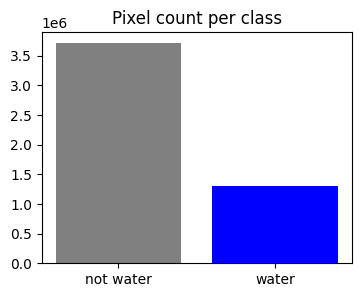

In [ ]:
# bar chart of the class distribution
plt.figure(figsize=(4, 3))
plt.bar(["not water", "water"], [all_pixels - water_pixels, water_pixels], color=["gray", "blue"])
plt.title("Pixel count per class")
plt.show()

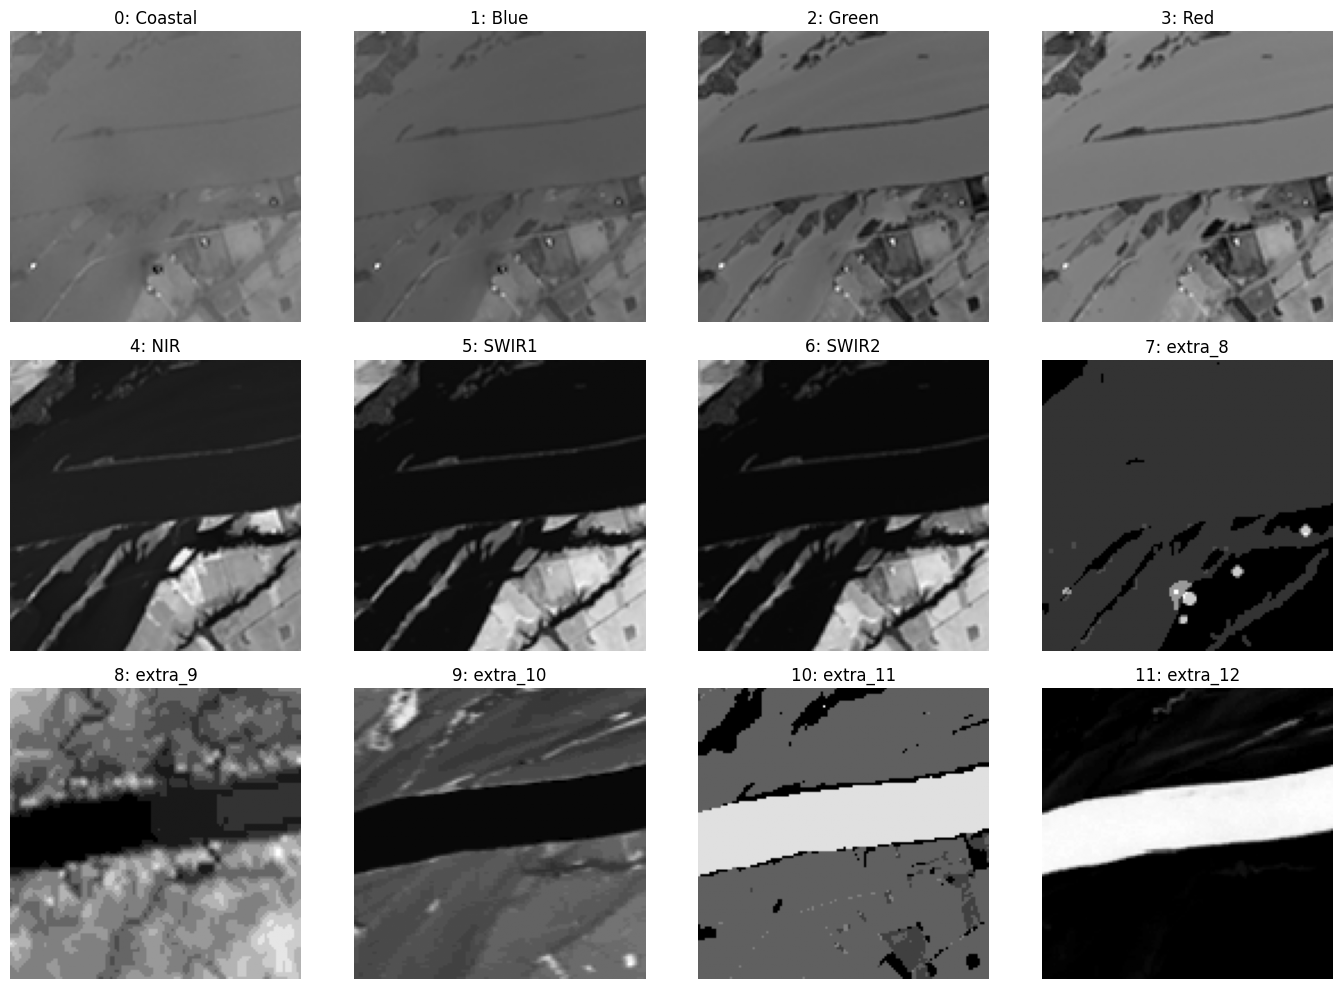

In [ ]:
# pick a sample that has a good amount of water
idx = int(np.argmax(water_per_image > 0.15)) if (water_per_image > 0.15).any() else 0
img = images[idx]
mask = masks[idx, 0]

plt.figure(figsize=(14, 10))
for b in range(12):
    plt.subplot(3, 4, b + 1)
    plt.imshow(img[b], cmap="gray")
    plt.title("%d: %s" % (b, BAND_NAMES[b]))
    plt.axis("off")
plt.tight_layout()
plt.show()

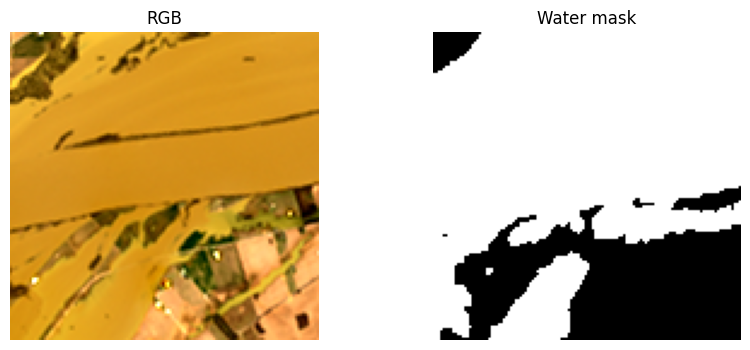

In [ ]:
def make_rgb(img):
    rgb = np.stack([img[RED], img[GREEN], img[BLUE]], axis=-1)
    # stretch the values so the picture is not too dark
    low, high = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip((rgb - low) / (high - low + 1e-6), 0, 1)
    return rgb

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(make_rgb(img))
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Water mask")
plt.axis("off")
plt.show()

In [ ]:
def add_indices(x):
    # x shape: (N, 12, H, W)  -> returns (N, 16, H, W)
    eps = 1e-6
    green = x[:, GREEN]
    red = x[:, RED]
    nir = x[:, NIR]
    swir1 = x[:, SWIR1]
    swir2 = x[:, SWIR2]

    ndwi = (green - nir) / (green + nir + eps)
    mndwi = (green - swir1) / (green + swir1 + eps)
    ndvi = (nir - red) / (nir + red + eps)
    awei = 4 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    new_bands = np.stack([ndwi, mndwi, ndvi, awei], axis=1)
    return np.concatenate([x, new_bands], axis=1).astype(np.float32)


all_data = add_indices(images)
ALL_NAMES = BAND_NAMES + ["NDWI", "MNDWI", "NDVI", "AWEI"]
print("data with indices:", all_data.shape)

data with indices: (306, 16, 128, 128)


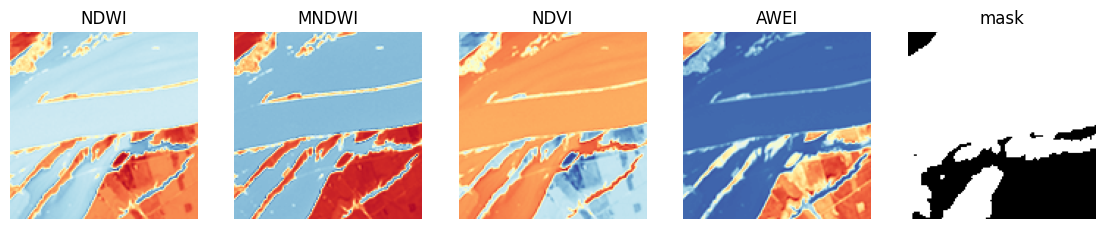

In [ ]:
# look at the indices for the same sample
plt.figure(figsize=(14, 3.5))
for i, name in enumerate(["NDWI", "MNDWI", "NDVI", "AWEI"]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(all_data[idx, 12 + i], cmap="RdYlBu")
    plt.title(name)
    plt.axis("off")
plt.subplot(1, 5, 5)
plt.imshow(mask, cmap="gray")
plt.title("mask")
plt.axis("off")
plt.show()

In [ ]:
# split 80% train / 20% validation
n = all_data.shape[0]
order = np.random.permutation(n)
split = int(0.8 * n)
train_idx, val_idx = order[:split], order[split:]

X_train, y_train = all_data[train_idx], masks[train_idx]
X_val, y_val = all_data[val_idx], masks[val_idx]
print("train:", X_train.shape, " val:", X_val.shape)

# min and max for each channel from the TRAIN set only
ch_min = X_train.min(axis=(0, 2, 3), keepdims=True)   # shape (1, C, 1, 1)
ch_max = X_train.max(axis=(0, 2, 3), keepdims=True)

def normalize(x):
    x = (x - ch_min) / (ch_max - ch_min + 1e-6)
    return np.clip(x, 0, 1).astype(np.float32)   # clip because val can go outside train range

X_train_n = normalize(X_train)
X_val_n = normalize(X_val)

# check the shape of one sample and the value range
print("one sample shape (12 bands only):", X_train_n[0, :12].shape)
print("min:", X_train_n.min(), " max:", X_train_n.max())

# save stats so I can use them later for new images
np.savez("norm_stats.npz", ch_min=ch_min, ch_max=ch_max)

train: (244, 16, 128, 128)  val: (62, 16, 128, 128)
one sample shape (12 bands only): (12, 128, 128)
min: 0.0  max: 1.0


In [ ]:
class WaterDataset(Dataset):
    def __init__(self, images, masks, use_aug=False):
        self.images = images
        self.masks = masks
        self.use_aug = use_aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = self.images[i]
        y = self.masks[i]

        if self.use_aug:
            # random flips (same flip for image and mask)
            if random.random() < 0.5:
                x = np.flip(x, axis=2)
                y = np.flip(y, axis=2)
            if random.random() < 0.5:
                x = np.flip(x, axis=1)
                y = np.flip(y, axis=1)
            # random 90 degree rotation
            k = random.randint(0, 3)
            x = np.rot90(x, k, axes=(1, 2))
            y = np.rot90(y, k, axes=(1, 2))

        return torch.from_numpy(x.copy()), torch.from_numpy(y.copy())

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, base=32, dropout=0.0):
        super().__init__()
        # encoder
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        # bottom
        self.bottom = DoubleConv(base * 8, base * 16)
        self.drop = nn.Dropout2d(dropout)

        # decoder
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        # 1 output channel = water logit (binary)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.drop(self.bottom(self.pool(e4)))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))   # skip connection
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


# quick test: input (batch, 12, 128, 128) should give output (batch, 1, 128, 128)
test_model = UNet(in_channels=12)
print(test_model(torch.randn(2, 12, 128, 128)).shape)

torch.Size([2, 1, 128, 128])


In [ ]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(1, 2, 3))
    total = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * inter + 1) / (total + 1)
    return 1 - dice.mean()

def loss_fn(logits, targets):
    return bce(logits, targets) + dice_loss(logits, targets)


def evaluate(model, loader):
    model.eval()
    tp = fp = fn = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = (torch.sigmoid(model(x)) > 0.5).float()
            tp += (pred * y).sum().item()
            fp += (pred * (1 - y)).sum().item()
            fn += ((1 - pred) * y).sum().item()
    eps = 1e-6
    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return {"iou": iou, "precision": precision, "recall": recall, "f1": f1}

In [ ]:
def train_model(channels, name, epochs=30, batch_size=16, lr=1e-3, base=32, dropout=0.0, use_aug=False):
    # channels = list of channel numbers to use as input
    train_ds = WaterDataset(X_train_n[:, channels], y_train, use_aug=use_aug)
    val_ds = WaterDataset(X_val_n[:, channels], y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = UNet(in_channels=len(channels), base=base, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # lower the learning rate when val IoU stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_iou = 0
    best_path = name + "_best.pth"
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scores = evaluate(model, val_loader)
        scheduler.step(scores["iou"])
        history.append(scores)

        if scores["iou"] > best_iou:
            best_iou = scores["iou"]
            torch.save(model.state_dict(), best_path)

        print("epoch %2d | loss %.4f | val IoU %.4f | val F1 %.4f" %
              (epoch + 1, total_loss / len(train_loader), scores["iou"], scores["f1"]))

    # load the best weights and report the final scores
    model.load_state_dict(torch.load(best_path, map_location=device))
    final = evaluate(model, val_loader)
    print()
    print(name, "FINAL validation scores:")
    for k, v in final.items():
        print("  %-9s %.4f" % (k, v))
    return model, final, history

In [ ]:
base_channels = list(range(12))
baseline_model, baseline_scores, baseline_hist = train_model(
    base_channels, "baseline_12ch", epochs=30, use_aug=False)

epoch  1 | loss 1.1740 | val IoU 0.5641 | val F1 0.7213
epoch  2 | loss 1.0109 | val IoU 0.5741 | val F1 0.7295
epoch  3 | loss 0.9520 | val IoU 0.5804 | val F1 0.7345
epoch  4 | loss 0.9303 | val IoU 0.5587 | val F1 0.7169
epoch  5 | loss 0.8857 | val IoU 0.6196 | val F1 0.7651
epoch  6 | loss 0.8595 | val IoU 0.6364 | val F1 0.7778
epoch  7 | loss 0.8308 | val IoU 0.6326 | val F1 0.7749
epoch  8 | loss 0.8085 | val IoU 0.6118 | val F1 0.7592
epoch  9 | loss 0.7934 | val IoU 0.6189 | val F1 0.7646
epoch 10 | loss 0.8064 | val IoU 0.6468 | val F1 0.7855
epoch 11 | loss 0.7983 | val IoU 0.5120 | val F1 0.6773
epoch 12 | loss 0.7972 | val IoU 0.6316 | val F1 0.7742
epoch 13 | loss 0.7987 | val IoU 0.6438 | val F1 0.7833
epoch 14 | loss 0.7612 | val IoU 0.6351 | val F1 0.7768
epoch 15 | loss 0.7525 | val IoU 0.6361 | val F1 0.7776
epoch 16 | loss 0.7237 | val IoU 0.6554 | val F1 0.7918
epoch 17 | loss 0.7267 | val IoU 0.6605 | val F1 0.7956
epoch 18 | loss 0.7319 | val IoU 0.6402 | val F1

In [ ]:
all_channels = list(range(16))
improved_model, improved_scores, improved_hist = train_model(
    all_channels, "improved_16ch", epochs=40, use_aug=True, dropout=0.2)

epoch  1 | loss 1.0796 | val IoU 0.3114 | val F1 0.4749
epoch  2 | loss 0.9317 | val IoU 0.5631 | val F1 0.7205
epoch  3 | loss 0.8882 | val IoU 0.5719 | val F1 0.7276
epoch  4 | loss 0.8767 | val IoU 0.6091 | val F1 0.7571
epoch  5 | loss 0.8337 | val IoU 0.6146 | val F1 0.7613
epoch  6 | loss 0.8463 | val IoU 0.6321 | val F1 0.7746
epoch  7 | loss 0.8234 | val IoU 0.5816 | val F1 0.7355
epoch  8 | loss 0.7985 | val IoU 0.6314 | val F1 0.7740
epoch  9 | loss 0.8098 | val IoU 0.5614 | val F1 0.7191
epoch 10 | loss 0.7780 | val IoU 0.6337 | val F1 0.7758
epoch 11 | loss 0.7893 | val IoU 0.6113 | val F1 0.7587
epoch 12 | loss 0.7449 | val IoU 0.6173 | val F1 0.7634
epoch 13 | loss 0.7705 | val IoU 0.5697 | val F1 0.7259
epoch 14 | loss 0.7607 | val IoU 0.6152 | val F1 0.7617
epoch 15 | loss 0.7608 | val IoU 0.6226 | val F1 0.7674
epoch 16 | loss 0.7277 | val IoU 0.6228 | val F1 0.7676
epoch 17 | loss 0.7255 | val IoU 0.6463 | val F1 0.7852
epoch 18 | loss 0.7118 | val IoU 0.6466 | val F1

model               IoU  precision   recall       F1
baseline 12ch    0.6704     0.7661   0.8429   0.8027
improved 16ch    0.6656     0.8000   0.7984   0.7992


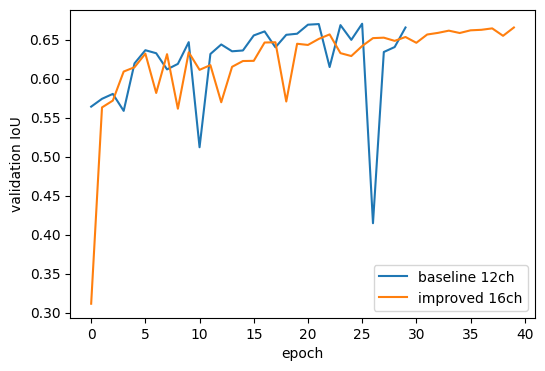

FINAL validation IoU (improved model): 0.6656


In [ ]:
print("%-14s %8s %10s %8s %8s" % ("model", "IoU", "precision", "recall", "F1"))
for name, s in [("baseline 12ch", baseline_scores), ("improved 16ch", improved_scores)]:
    print("%-14s %8.4f %10.4f %8.4f %8.4f" % (name, s["iou"], s["precision"], s["recall"], s["f1"]))

# learning curves
plt.figure(figsize=(6, 4))
plt.plot([h["iou"] for h in baseline_hist], label="baseline 12ch")
plt.plot([h["iou"] for h in improved_hist], label="improved 16ch")
plt.xlabel("epoch")
plt.ylabel("validation IoU")
plt.legend()
plt.show()

print("FINAL validation IoU (improved model): %.4f" % improved_scores["iou"])

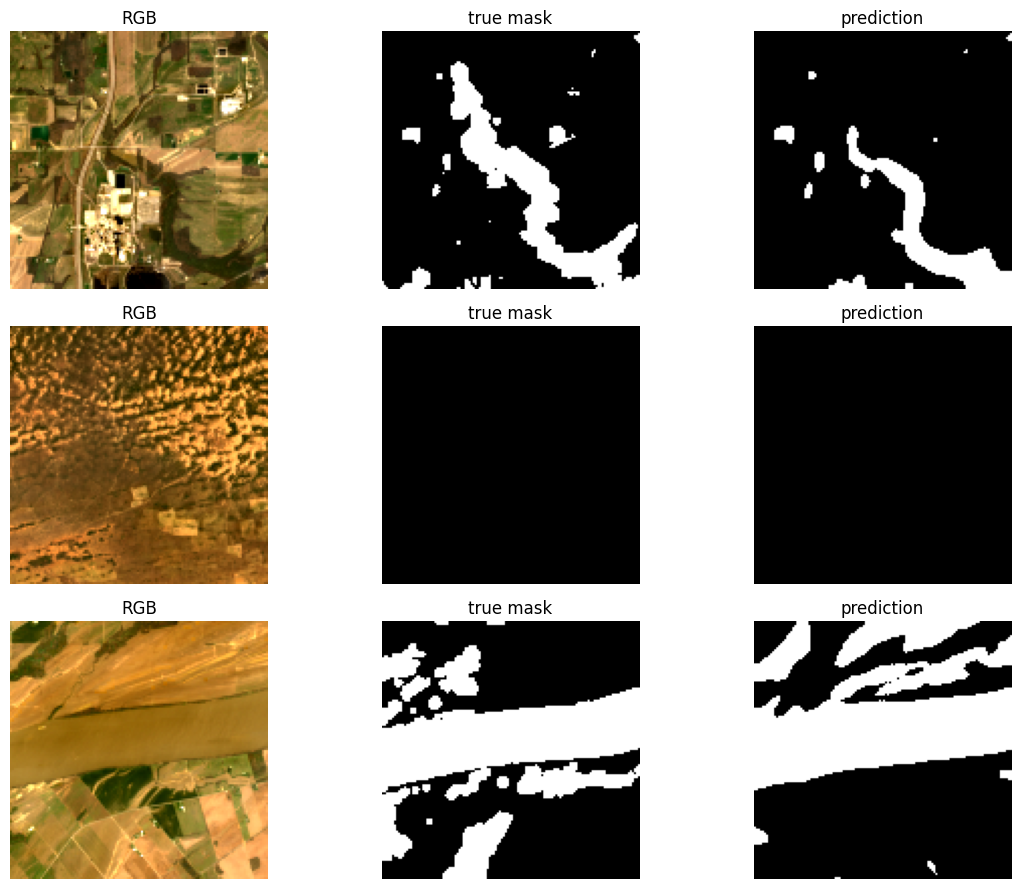

In [ ]:
improved_model.eval()
plt.figure(figsize=(12, 9))
for row in range(3):
    i = row * 5   # just some samples from the validation set
    x = torch.from_numpy(X_val_n[i:i + 1]).to(device)
    with torch.no_grad():
        pred = (torch.sigmoid(improved_model(x)) > 0.5).float().cpu().numpy()[0, 0]

    plt.subplot(3, 3, row * 3 + 1)
    plt.imshow(make_rgb(X_val[i]))
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(3, 3, row * 3 + 2)
    plt.imshow(y_val[i, 0], cmap="gray")
    plt.title("true mask")
    plt.axis("off")

    plt.subplot(3, 3, row * 3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("prediction")
    plt.axis("off")
plt.tight_layout()
plt.show()